# Advanced RAG Experiment: Baseline Cross-Encoder vs BERT-Base Rerankers

- Task: Multi-document / multi-hop QA (HotpotQA subset)
- Retriever: sentence-transformers embeddings + FAISS
- Rerankers:
  - Baseline: prebuilt CrossEncoder (fast baseline)
  - Advanced: **BERT-base** used as cross-encoder
- Answer model: `bert-large-...-SQuAD` (extractive)
- Evaluation: Retrieval Recall@K, end-to-end EM & F1.

Downloads:

In [1]:
# Note: installing faiss-cpu here. If you have CUDA GPU and want faiss-gpu, change accordingly.
!pip install --upgrade pip
!pip install transformers sentence-transformers datasets faiss-cpu scikit-learn tqdm matplotlib
!pip install git+https://github.com/UKPLab/sentence-transformers.git@master
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 90.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 92.4 MB/s  0:00:00
  Cloning https://github.com/UKPLab/sentence-transformers.git (to revision master) to /tmp/pip-req-build-bqrcjugt
  Running command git clone --filter=blob:none --quiet https://github.com/UKPLab/sentence-transformers.git /tmp/pip-req-build-bqrcjugt
  Resolved https://github.com/UKPLab/sentence-transformers.git to commit 85ec64559f4414aa536eca4bf53538291e0a333f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for sentence-transformers: filename=sentence_transformers-5.2.0.dev0-py3-none-any.whl size=484984 sha256=11b5ee8578b1c558a1268bdbccf0463af5f73b6d037f9c2ea084b14df03a77f3
  Stored in director

Imports:

In [2]:
import os
import time
import math
from typing import List, Tuple
from datasets import load_dataset
from evaluate import load
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, BertTokenizer, BertForSequenceClassification
import faiss
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
from tqdm.auto import tqdm
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Dataset Preparation:

Makes a small datasubset from the HotpotQA dataset and processes it by using a passages and queries subdatasets.

In [30]:
print("Downloading HotpotQA subset (this may take a minute)...")
dataset = load_dataset("hotpot_qa", "distractor")

SAMPLE_N = 200
examples = dataset["train"].select(range(SAMPLE_N))

print("Preparing passages...")
passages = []  # list looking like: {"id": ..., "text": ..., "meta": ...}

for i, ex in enumerate(examples):
    doc_id = ex["id"]
    titles = ex["context"]["title"]
    paragraphs = ex["context"]["sentences"]

    for j, (title, sentences) in enumerate(zip(titles, paragraphs)):
        text = " ".join(sentences)
        meta = {"hotpot_id": doc_id, "title": title, "para_idx": j}
        passages.append({"id": f"{doc_id}_{j}", "text": text, "meta": meta})

print(f"Built {len(passages)} passages.")

# Build map from example id -> question + answer for evaluation

queries = []

for ex in examples:
    q = ex["question"]
    ans = ex.get("answer", "")
    queries.append({"id": ex["id"], "question": q, "gold_answers": [ans]})

print("Prepared queries:", len(queries))

Preparing passages...
Built 2000 passages.
Prepared queries: 200


Embedding Model:

Loads a dense retriever encoder model for converting passages to embeddings and building the indices for similarity search (top-k relevant passages for a questiuon).

This gives initial index candidates for the RAG system.

In [31]:
from sentence_transformers import SentenceTransformer

EMBEDDER_MODEL = "sentence-transformers/all-mpnet-base-v2"

print(f"Loading embedder model: {EMBEDDER_MODEL}")
embedder = SentenceTransformer(EMBEDDER_MODEL)

sample_vec = embedder.encode(["test passage"], convert_to_numpy=True)
print("Embedder ready, vector dim:", sample_vec.shape[1])

Loading embedder model: sentence-transformers/all-mpnet-base-v2
Embedder ready, vector dim: 768


FAISS Index Construction:

This is where the encoding of passages into batches and adding them to the inner-product index. This normalizes vectors as well for cosine similarity.

In [32]:
# Create batches
texts = [p["text"] for p in passages]
batch_size = 64
embeddings = []

for i in tqdm(range(0, len(texts), batch_size), desc="Embedding passages"):
    batch = texts[i:i+batch_size]
    emb = embedder.encode(batch, convert_to_numpy=True, show_progress_bar=False)
    embeddings.append(emb)

embeddings = np.vstack(embeddings).astype("float32")

# Build FAISS Index

dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)  # inner product (we will normalize embeddings)
faiss.normalize_L2(embeddings)
index.add(embeddings)
print("FAISS index size:", index.ntotal)

Embedding passages: 100%|██████████| 32/32 [00:30<00:00,  1.06it/s]

FAISS index size: 2000


Retrieval Test:

Test to ensure meaningful text is returned for a question.

In [34]:
def retrieve_top_k(query: str, k:int=10):
    q_emb = embedder.encode([query], convert_to_numpy=True)
    q_emb = q_emb.astype("float32")
    faiss.normalize_L2(q_emb)
    D, I = index.search(q_emb, k)
    results = []

    for idx in I[0]:
        results.append(passages[int(idx)])

    return results

print("Retrieving for a sample query...")
print(queries[0]["question"])
print(retrieve_top_k(queries[0]["question"], k=3))


Retrieving for a sample query...
Which magazine was started first Arthur's Magazine or First for Women?
[{'id': '5a7a06935542990198eaf050_5', 'text': 'Arthur\'s Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.  Edited by T.S. Arthur, it featured work by Edgar A. Poe, J.H. Ingraham, Sarah Josepha Hale, Thomas G. Spear, and others.  In May 1846 it was merged into "Godey\'s Lady\'s Book".', 'meta': {'hotpot_id': '5a7a06935542990198eaf050', 'title': "Arthur's Magazine", 'para_idx': 5}}, {'id': '5ac061ab554299294b218fac_1', 'text': "First for Women is a woman's magazine published by Bauer Media Group in the USA.  The magazine was started in 1989.  It is based in Englewood Cliffs, New Jersey.  In 2011 the circulation of the magazine was 1,310,696 copies.", 'meta': {'hotpot_id': '5ac061ab554299294b218fac', 'title': 'First for Women', 'para_idx': 1}}, {'id': '5a7a06935542990198eaf050_7', 'text': "First for Women is a woman's magazine publi

Set-up the two reranker variations:

This includes the baseline with the Cross Encoder method, and the BERT-base-uncased variation.

In [9]:
from sentence_transformers import CrossEncoder
from transformers import BertTokenizer, BertForSequenceClassification
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on device:", device)

# baseline with cross-encoder
BASELINE_RERANKER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
print(f"Loading baseline cross-encoder: {BASELINE_RERANKER_MODEL}")
baseline_cross_encoder = CrossEncoder(BASELINE_RERANKER_MODEL, device=device)

# BERT-LLM variation
RERANKER_BASE_MODEL = "bert-base-uncased"
print(f"Loading advanced reranker model: {RERANKER_BASE_MODEL}")
reranker_tokenizer = BertTokenizer.from_pretrained(RERANKER_BASE_MODEL)
reranker_model = BertForSequenceClassification.from_pretrained(RERANKER_BASE_MODEL, num_labels=1).to(device)

Running on device: cuda
Loading baseline cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Reranking Functions:

Baseline returns cross-encoder scores for top-k passages.
BERT-base concatenates query and candidate pairs and returns the model scores as logits.

In [10]:
# Baseline variaton
def baseline_rerank(query: str, candidates: List[dict], topk: int=5):
    pairs = [(query, c["text"]) for c in candidates]
    scores = baseline_cross_encoder.predict(pairs)  # higher = better
    scored = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [c for c, s in scored[:topk]]

# BERT-Base variation
def bertbase_rerank(query: str, candidates: List[dict], topk: int=5):
    inputs = ["[CLS] " + query + " [SEP] " + c["text"] for c in candidates]
    enc = reranker_tokenizer(inputs, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

    with torch.no_grad():
        out = reranker_model(**enc)
        logits = out.logits.squeeze(-1).cpu().numpy()

    scored = sorted(zip(candidates, logits), key=lambda x: x[1], reverse=True)
    return [c for c, s in scored[:topk]]


QA Reader Setup:

Loads the QA model for processing

In [12]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

QA_MODEL_NAME = "deepset/roberta-base-squad2"

print(f"Loading QA model: {QA_MODEL_NAME}")
qa_tokenizer = AutoTokenizer.from_pretrained(QA_MODEL_NAME)
qa_model = AutoModelForQuestionAnswering.from_pretrained(QA_MODEL_NAME).to(device)

print("QA model and tokenizer ready.")

Loading QA model: deepset/roberta-base-squad2


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

QA model and tokenizer ready.


QA Pipeline Function:

Wraps it to take questions and passages and returns predicted answers and confidence scores.

In [14]:
from transformers import pipeline

qa_pipeline = pipeline(
    "question-answering",
    model=qa_model,
    tokenizer=qa_tokenizer,
    device=0 if device == "cuda" else -1
)

def answer_from_passage(question: str, passage_text: str):
    try:
        res = qa_pipeline(question=question, context=passage_text, top_k=1)

        if isinstance(res, list):
            res = res[0]

        return res.get("answer", ""), res.get("score", 0.0)

    except Exception:
        return "", 0.0


Device set to use cuda:0


Full Pipeline:

1. Retrieves top-x passages from FAISS RAG Index system.
2. Reranks them via Cross Encoder or BERT-Baseline
3. Send top-3 to the QA model.
4. Pick the passage yielding highest QA confidence score.

In [15]:
# Pipeline:
def run_rag_pipeline(question: str, rerank_method="baseline", top_k_retrieve=10, top_k_rerank=3):
    candidates = retrieve_top_k(question, k=top_k_retrieve)

    if rerank_method == "baseline":
        ranked = baseline_rerank(question, candidates, topk=top_k_rerank)

    elif rerank_method == "bertbase":
        ranked = bertbase_rerank(question, candidates, topk=top_k_rerank)

    else:
        raise ValueError("rerank_method must be 'baseline' or 'bertbase'")

    # Generate answers

    answers = []

    for p in ranked:
        a, sc = answer_from_passage(question, p["text"])
        answers.append({"answer": a, "score": sc, "passage_meta": p["meta"]})

    # Select best QA score

    best = max(answers, key=lambda x: x["score"]) if answers else {"answer":"", "score":0}
    return best, ranked, answers


Test an example:

In [17]:
def retrieve_top_k(query, k=10):
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, idxs = index.search(q_emb, k)
    return [passages[i] for i in idxs[0]]

q = queries[0]["question"]
cands = retrieve_top_k(q, k=10)
top_passage = baseline_rerank(q, cands, topk=1)[0]

print("Question:", q)
print("Top passage snippet:", top_passage["text"][:250])

ans, conf = answer_from_passage(q, top_passage["text"])
print("Predicted answer:", ans, f"(confidence={conf:.3f})")


Question: Which magazine was started first Arthur's Magazine or First for Women?
Top passage snippet: First for Women is a woman's magazine published by Bauer Media Group in the USA.  The magazine was started in 1989.  It is based in Englewood Cliffs, New Jersey.  In 2011 the circulation of the magazine was 1,310,696 copies.
Predicted answer: First for Women (confidence=0.001)


Evaluation Loop:

Runs RAG pipeline on multiple queries and computes:
1. Exact Matches - How many answers match the ground truth (%).
2. F1 Scores - Word-level overlap between pred and true answers.
3. Recall@k - how often the gold answer text appears in top-k retrieved passages.

Compares Baseline Cross Encoder with the BERT-Base variations.

In [19]:
import numpy as np
from tqdm import tqdm
import evaluate

squad_metric = evaluate.load("squad")

def evaluate_system(queries_to_eval, rerank_method="baseline", n_eval=50):
    n_eval = min(n_eval, len(queries_to_eval))
    subset = queries_to_eval[:n_eval]
    ems = []
    f1s = []
    recall_counts = {"r@1":0, "r@5":0, "r@10":0}
    for q in tqdm(subset, desc=f"Evaluating ({rerank_method})"):
        question = q["question"]
        golds = q["gold_answers"]

        # Retrieval recall @k

        cands = retrieve_top_k(question, k=10)
        top_texts = [c["text"] for c in cands]

        # If any top passage contains gold answer substring, count as recall

        for k in [1,5,10]:
            if any(any(g in t for g in golds if g) for t in top_texts[:k]):
                recall_counts[f"r@{k}"] += 1

        # End-to-end

        best, _, _ = run_rag_pipeline(question, rerank_method=rerank_method, top_k_retrieve=10, top_k_rerank=3)
        pred = {"id": q["id"], "prediction_text": best["answer"]}
        references = [{"id": q["id"], "answers": {"text": golds, "answer_start": [0]*len(golds) if golds else [-1]}}]

        try:
            result = squad_metric.compute(predictions=[pred], references=references)
            ems.append(result["exact_match"])
            f1s.append(result["f1"])

        except Exception:
            ems.append(0.0)
            f1s.append(0.0)

    # averages

    out = {
        "EM": float(np.mean(ems)),
        "F1": float(np.mean(f1s)),
        "Recall@1": recall_counts["r@1"]/n_eval,
        "Recall@5": recall_counts["r@5"]/n_eval,
        "Recall@10": recall_counts["r@10"]/n_eval
    }

    return out

# Quick evaluation on a small set (takes time)
res_baseline = evaluate_system(queries, rerank_method="baseline", n_eval=40)
res_bertbase = evaluate_system(queries, rerank_method="bertbase", n_eval=40)
print("Baseline (CrossEncoder) results:", res_baseline)
print("Advanced (BERT-base reranker, un-finetuned) results:", res_bertbase)


Evaluating (bertbase): 100%|██████████| 40/40 [00:09<00:00,  4.04it/s]

Baseline (CrossEncoder) results: {'EM': 45.0, 'F1': 50.33333333333333, 'Recall@1': 0.425, 'Recall@5': 0.75, 'Recall@10': 0.825}
Advanced (BERT-base reranker, un-finetuned) results: {'EM': 27.5, 'F1': 34.83333333333333, 'Recall@1': 0.425, 'Recall@5': 0.75, 'Recall@10': 0.825}


Example Cross Encoder Scoring Cell:

In [20]:
from sentence_transformers import CrossEncoder

reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# For each query + candidate passage, get relevance scores

scores = []
for q in queries[:5]:
    pairs = [(q["question"], p["text"]) for p in passages[:50]]
    s = reranker_model.predict(pairs)
    top_idx = int(np.argmax(s))
    top_passage = passages[top_idx]
    scores.append((q["question"], top_passage["text"], float(max(s))))

print(scores[0])


("Which magazine was started first Arthur's Magazine or First for Women?", "First for Women is a woman's magazine published by Bauer Media Group in the USA.  The magazine was started in 1989.  It is based in Englewood Cliffs, New Jersey.  In 2011 the circulation of the magazine was 1,310,696 copies.", 6.649274826049805)


Visualizations Reporting Differences Among Variations:

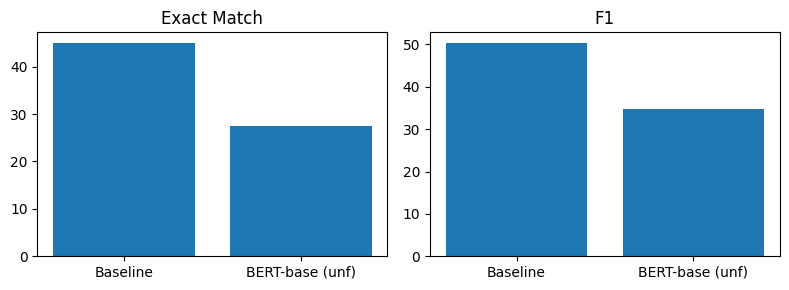

In [21]:
import matplotlib.pyplot as plt

labels = ["Baseline", "BERT-base (unf)"]
ems_vals = [res_baseline["EM"], res_bertbase["EM"]]
f1_vals = [res_baseline["F1"], res_bertbase["F1"]]

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.bar(labels, ems_vals); plt.title("Exact Match")
plt.subplot(1,2,2)
plt.bar(labels, f1_vals); plt.title("F1")
plt.tight_layout()
plt.show()
